# Model Reference Adaptive Control (MRAC) Tutorial

## 01. Motivation
In classical control methods we design the controllers based on some abstraction or model we create from the system. However the real world is complex and there are a lot of situations we don't control:
* **Unknown parameters**: This is the responsibility for the system identification task and even though we can estimate some parameters of the system, sometimes they are difficult to acquire. For example estimating the friction coefficient of each tire of my car respect to one surface.
* **Time-varying dynamics**: Recalling the car example, car tires wear down with use, so their coefficient of friction changes over time.
* **Environment**: The friction coefficient as well depends on the surface, that might change depending on the road.

There are several approaches that seek to solve this issue:
* **Robust control**: The idea is to create a single controller able to handle all the uncertainty, basically to be prepared for the worst case scenario. This is okay, but it tends to be overconservative and it might not perform optimally during normal operation, for example using a tank to kill a fly.
* **Gain-scheduling**: If we expect some scenarios, we can desing several controllers for each operating point and transition across them. This is very reliable, but we need to account for the changes. One unexpected scenario recalling the car example might be when the car gets a flat tire, now the behavior is not simply updating the friction coefficient.
* **Adaptive control**: The idea is to update the parameters online. Like active learning. Specifically the MRAC watches the error between the plant and the reference model and changes its gains on the fly to close that gap.

## 02. MRAC with Linear Reference Model

### The Plant:
Consider a MIMO LTI uncertain system that follows the dynamics:
$$\dot{x}(t) = A x(t) + B u(t)$$
where $x$ is the state, $u$ is the input of the system, and $A$ and $B$ are **unknown** constant parameters we need to handle.

### The Reference Model
The reference model could follow two design philosophies:
* The "ideal designer" approach: Here we can specify in the best case what would be the desired behavior of the system, e.g. "I want this motor to settle in 0.5 seconds with no overshoot". This is basically pole-placement.
* The "Sim-to-Real" approach: The reference model is our high-fidelity simulation. We trust our simulation, and we want the physical hardware to match that behavior exactly, even if there's friction or mass we didn't account for in the real world.

The reference model has the following form:
$$\dot{x_m}(t) =  A_m x_m(t) + B_m r(t)$$
We choose $A_m$ and $B_m$ following one of the philosophies. For this case we follow the "ideal designer" approach and we set $A_m$ and $B_m$ to give us the desired performance (like how fast the system responds)

### Control law
Now, the idea is to match my real plant with my reference model. For our plant $\dot{x} = Ax + Bu$ to mathematically transform into the model $\dot{x}_m = A_m x_m + B_m r$, we need a term that modifies the state ($x$) and a term that scales the reference ($r$). The control output follows a feedback-feedforward controller.
$$u(t) = K_r(t) r(t) - K_x(t) x(t) $$
Pd: Some authors state the control with a "positive feedback" as $u(t) = K_r(t) r(t) + K_x(t) x(t)$, I mean it doesn't matter as long as the convention follows, and the stability criteria holds (probably the algorithm will converge to negative value), but they are equivalent
The goal is to determine $K_x(t)$ and $ K_r(t)$ so that the **closed-loop** of the real system matches the reference model. Note that they are time-variant terms.

Let's plug $u(t)$ into the plant:
$$
\dot{x} = A x + B (K_r r-K_x x)\\
$$
reorganizing:
$$
\dot{x} = (A-B K_x) x + (B K_r)  r\\
$$

#### Model Matching conditions
For the plant to behave exactly like the model ($x \to x_m$), the coefficients in front of $x$ and $r$ must match the coefficients in the reference model. This gives us two algebraic equations:
1.  **State matching:** $A - BK_x = A_m$
2.  **Input matching:** $BK_r = B_m$

#### Tracking error
Let's substract the state of each system to produce an error signal:
$$
e = x - x_m
$$
Let's analyze how the tracking error $e(t)$ evolves over time, by finding its derivative
$$
\dot{e} = \dot{x} - \dot{x}_m
$$

Substituting our plant with the control law $u = K_r r - K_x x$ and our reference model, we get:
$$\dot{e} = [Ax + B(K_r r - K_x x)] - [A_m x_m + B_m r]$$

reorganizing:
$$\dot{e} = (A-B K_x) x + B K_r  r - A_m x_m - B_m r$$

If we pick $K_x$ and $K_r$ so that it fulfills the matching condition, then we get
$$\dot{e} = A_m (x-x_m) = A_m e$$
Now, $A_m$ is the state matrix of our model, so if we pick $A_m \succ 0$ so that it's Hurwitz, then the error $e \to 0$ will converge to zero as the time $t \to \infty$ goes to infinity.

However this implies we know the optimal values of $K_x$ and $K_r$, which it means we fully know the parameters of the system. Since we **don't** know $A$ and $B$ in the real world, we can't pre-calculate those ideal $K^*$ values. Instead we can estimate the parameter error, let's define it as:
$$
\tilde{K}(t) = K(t) - K^*(t)
$$

Recovering the dynamics
$$\dot{e} = (A-B K_x) x + B K_r  r - A_m x_m - B_m r$$
Let's add and subtract $A_m x$. The idea behind this is that we want to pair $+A_m x$ with our existing $-A_m x_m$ to form $A_m(x - x_m) = A_m e$.
$$\dot{e} = (A-B K_x) x + B K_r  r - A_m x_m - B_m r + (A_m x_m-A_m x_m)$$
Now grouping in terms of $x$ and $r$:
$$\dot{e} = A_m e + (A-B K_x-A_m) x + (B K_r - B_m) r $$

Recalling the **Matching conditions**: if we had the ideal gains $K_r^*$ and $K_x^*$, then the terms in the parenthesis would be zero:
$$A-B K_x^*-A_m = 0 $$
$$B K_r^* - B_m = 0 $$
If we replace $A$ and $B_m$ using these conditions, then we get:
$$\dot{e} = A_m e + (B K_x^* + A_m -B K_x-A_m) x + (B K_r - B K_r^*) r $$
Simplifying:
$$\dot{e} = A_m e + B(K_x^*-K_x) x + B(K_r - K_r^*) r $$
As defined before $\tilde{K} = K - K^*$:
$$\dot{e} = A_m e - B\tilde{K}_x x + B\tilde{K}_r r $$

#### Adaptive Law: The MIT Rule
The **MIT Rule** is one of the earliest and most intuitive methods for designing the adaptive law in MRAC. It was developed at the Massachusetts Institute of Technology in the late 1950s, primarily for flight control systems.
The MIT Rule is based on the **Gradient Descent** principle. The goal is to adjust the controller parameters (which we've been calling $K$) so that a specific cost function is minimized. 

Usually, we want to minimize the squared tracking error:
$$J(K) = \frac{1}{2} e^2(t)$$

To move "downhill" toward the minimum error, we change the parameters in the opposite direction of the gradient:
$$\dot{K} = -\gamma \frac{\partial J}{\partial K}$$

By applying the chain rule to our cost function $J$, we get the classic MIT Rule formula:
$$\dot{K} = -\gamma e \frac{\partial e}{\partial K}$$

* **$\gamma$ (Gamma)**: The **adaptation gain**. It determines how "aggressively" the controller learns.
* **$e$**: The current tracking error ($x - x_m$).
* **$\frac{\partial e}{\partial K}$**: The **sensitivity derivative**. This tells the controller how much the error changes when a parameter is tweaked.

#### Solving for $K_r$ and $K_x$

We can't just take a simple derivative of $e$ with respect to $K$ ($\frac{\partial e}{\partial K}$) because $e$ is trapped inside a **differential equation** ($\dot{e}$). To find the sensitivity, we have to solve that differential equation first.

Note: We will derive this using first a **SISO (Single-Input Single-Output)** representation (treating matrices as scalars), because the matrix-calculus version gets extremely dense with chain rules and trace operators, while the scalar version yields the exact same intuitive result!

Since the reference model $x_m$ is completely independent of our gains, so $\frac{\partial x_m}{\partial K} = 0$, meaning $\frac{\partial e}{\partial K} = \frac{\partial x}{\partial K}$, let's apply the Laplace transform to our closed-loop plant:
$$\dot{x} = (A - B K_x)x + B K_r r$$

Note: **The Laplace transform strictly only works for Linear Time-Invariant (LTI) systems.** In a true LTI system, parameters like $K_x$ and $K_r$ must be constants, but in MRAC, by definition, $K_x(t)$ and $K_r(t)$ are variables that change with time!
To allow this trick we need to assume slow adaption, otherwise taking the derivative would be a mathematical nightmare involving convolution integrals in the frequency domain. 

Assuming zero initial conditions, this becomes:
$$sX(s) = (A - B K_x)X(s) + B K_r R(s)$$

Now, let's group the $X(s)$ terms and solve for the plant state:
$$[s - (A - B K_x)]X(s) = B K_r R(s)$$
$$X(s) = \frac{B K_r}{s - A + B K_x} R(s)$$

##### Sensivity with respect to $K_r$
$$\frac{\partial X}{\partial K_r} = \frac{B}{s-(A-BK_x)} R(s)$$

##### Sensivity with respect to $K_x$
$$\frac{\partial X}{\partial K_x} = BK_r \cdot \frac{-(-B)}{(s-(A-BK_x))^2} R(s) = \frac{B}{s-(A-BK_x)} \cdot \underbrace{\frac{BK_r}{s-(A-BK_x)} R(s)}_{= X(s)}$$

$$\boxed{\frac{\partial X}{\partial K_x} = \frac{B}{s-(A-BK_x)} \cdot X(s)}$$

But there is a **critical problem**: Both sensitivies depend on $A$ and $B$, which are the **unknown** parameters we are trying to adapt.

The trick is: We assume that our controller is doing its job and successfully pushing the system toward the ideal behavior. Recall the **matching condition** we defined earlier for the state: $A - B K_x^* = A_m$

If the system is adapting well, then $K_x \approx K_x^*$, which means the denominator $s - A + B K_x$ is roughly equal to $s - A_m$. 
By swapping the unknown denominator with $s - A_m$, we get a filter we can actually build:
$$\frac{\partial e(s)}{\partial K_r} \approx \frac{B}{s - A_m} R(s)$$

$$\frac{\partial e(s)}{\partial K_x} \approx \frac{-B}{s - A_m} X(s)$$

If we let $p = \frac{d}{dt}$ or use the operator $1/(p - A_m)$ to represent that filter, the true MIT gradient update laws would be:

$$\dot{K}_r = -\gamma e \left( \frac{B}{p - A_m} r \right)$$
$$\dot{K}_x = -\gamma e \left( \frac{-B}{p - A_m} x \right) = \gamma e \left( \frac{B}{p - A_m} x \right)$$

*(Note: Just like before, since $B$ is an unknown constant, we usually absorb it into the user-defined adaptation gain $\gamma$!)*

In many textbook presentations and implementations, the filtering step is dropped entirely, giving the beautifully simple update laws:

$$\dot{K}_r = -\gamma_r \cdot e \cdot r, \qquad \dot{K}_x = \gamma_x \cdot e \cdot x$$

This works when the adaptation gain $\gamma$ is small — meaning adaptation is slow relative to the plant dynamics, so the filter's contribution washes out.

*(Note: The MIT rule is a **heuristic** derived from gradient descent. It is not provably stable. For large $\gamma$, or for certain persistent reference signals, the gains can drift and the system can go unstable. This is a well-known historical failure mode.)*

## 03. Hands on - Python implementation

Problem created by __Gemini__: **Cruise Control System of a car**

>Imagine a car of mass $m$ moving at velocity $v$. The engine provides a force $u$, but there is also a resistive force (drag/friction) $b$. The simplified physics (Newton's Second Law) gives us:
>$$m\dot{v} + bv = u$$
>
>To put this in our standard first-order form $\dot{x} = ax + bu$, we divide by $m$:
>$$\dot{v} = -\frac{b}{m}v + \frac{1}{m}u$$
>
>In this case:
>* $x$ is our velocity $v$.
>* $a = -b/m$ (This represents how the car naturally slows down due to friction).
>* $b_{p} = 1/m$ (This represents how much the acceleration "gains" from the engine force).
>
>### Why MRAC for a Car?
>In a real car, $m$ and $b$ aren't constant:
>1.  **Mass ($m$)**: Changes if you have 4 passengers vs. just the driver, or a full tank of gas vs. empty.
>2.  **Friction ($b$)**: Changes based on wind resistance or the road surface (smooth asphalt vs. gravel).

### The reference model
The Adaptive Cruise Control (ACC) is defined so that we want the car to reach the set speed $r$ smoothly. Typically we want to track the front car to keep a safety distance.
$$\dot{v}_m = a_m v_m + b_m r$$

#### 🚗 Realistic Parameters

* **Mass ($m$):** A standard car often weighs around **1500 kg**. This includes the chassis, engine, and a driver.
* **Drag/Friction Coefficient ($c_b$):** This is a bit more complex in reality because air resistance increases with the square of velocity ($v^2$), but for our **linearized** first-order model, we can approximate the total resistance (rolling resistance + air drag at highway speeds) with a constant $b \approx \mathbf{50 \text{ Ns/m}}$.

Let's say we want to maintain a steady speed of **30 m/s** (about 108 km/h or 67 mph). 

In a perfect world, to stay at that speed, the engine must exactly cancel out the friction. We calculate the required force $u$ using the steady-state equation ($\dot{v} = 0$):
$$0 = -\frac{c_b}{m}v + \frac{1}{m}u \implies u = c_b \cdot v$$
$$u = 50 \cdot 30 = \mathbf{1500 \text{ N}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Let's verify the reference system.
Pd: We are simulating using the first order euler step $x_{t+1} = x_{t} + \delta_t \dot{x}$

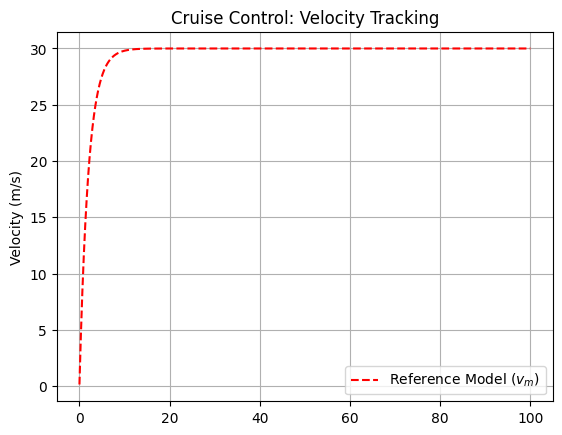

In [2]:
# Time step (seconds)
dt = 0.01
# Total simulation time
T = 100
time = np.arange(0, T, dt)

# Reference model parameters
a_m = -0.5
b_m = 0.5

# Actual plant parameters
c_b = 50
m = 1500

# Reference
r = 30

v_m = 0
history = {'v_m': []} 
for t in time:
    dvm_dt = a_m * v_m + b_m * r
    v_m += dvm_dt * dt
    history['v_m'].append(v_m)

plt.plot(time, history['v_m'], 'r--', label='Reference Model ($v_m$)')
plt.title('Cruise Control: Velocity Tracking')
plt.ylabel('Velocity (m/s)')
plt.grid()
plt.legend()

Now, let's imagine we are driving with that fixed force of **1500 N**. Suddenly, three heavy friends jump into the car and we put a large roof rack on top, instantly increasing the mass to **2000 kg** and the friction coefficient to **80 Ns/m**.

If the engine force $u$ stays exactly at **1500 N**, what will be the new "top speed" the car settles at with these heavier, draggier conditions?

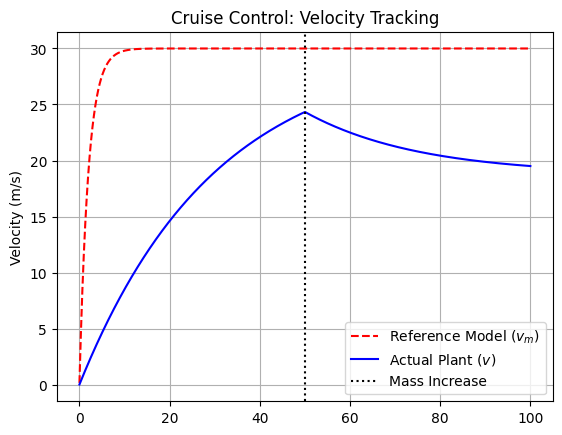

In [5]:
# Time step (seconds)
dt = 0.01
# Total simulation time
T = 100
time = np.arange(0, T, dt)

# Reference model parameters
a_m = -0.5
b_m = 0.5

# Actual plant parameters
c_b = 50
m = 1500

# Reference
r = 30

v= 0
v_m = 0

disturbance_time = 50

u = c_b*r

history = {'v': [], 'v_m': []} 
for t in time:
    # Introduce a disturbance: halfway through, the car gets much heavier!
    if t > disturbance_time:
        m = 2000.0 # Heavy cargo added
        c_b  = 80.0  # Drag increased

    # Reference model
    dvm_dt = a_m * v_m + b_m * r
    v_m += dvm_dt * dt
    
    # Plant Dynamics: dv/dt = -(b/m)*v + (1/m)*u
    dv_dt = -(c_b/m) * v + (1/m) * u
    v += dv_dt * dt
    
    history['v_m'].append(v_m)
    history['v'].append(v)

plt.plot(time, history['v_m'], 'r--', label='Reference Model ($v_m$)')
plt.plot(time, history['v'], 'b', label='Actual Plant ($v$)')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Cruise Control: Velocity Tracking')
plt.ylabel('Velocity (m/s)')
plt.grid()
plt.legend()

### Adaptive controller

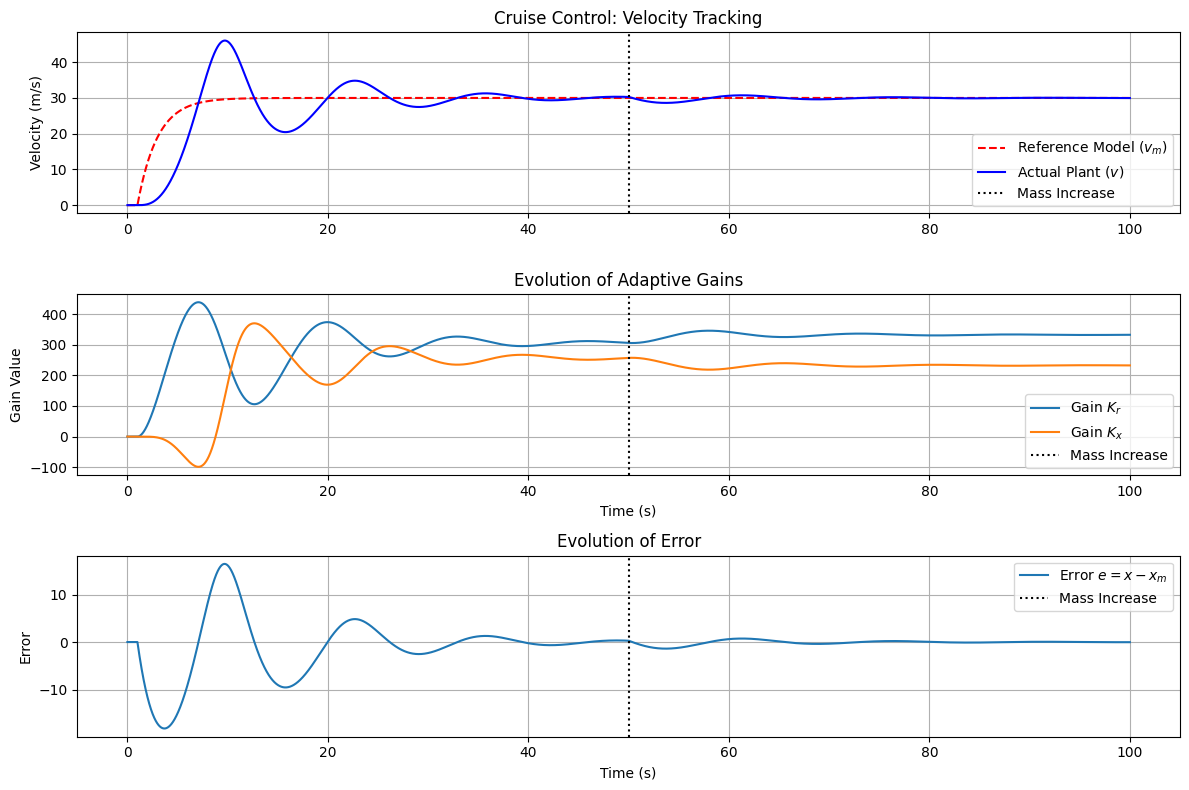

In [6]:
# Time step (seconds)
dt = 0.01
# Total simulation time
T = 100
time = np.arange(0, T, dt)

# Reference model parameters
a_m = -0.5
b_m = 0.5

# Actual plant parameters
c_b = 50
m = 1500

# Initialize States
v = 0.0
v_m = 0.0
K_r = 0.0
K_x = 0.0

disturbance_time = 50

gamma = 0.2  # Learning rate (try changing this later!)

history = {'v': [], 'v_m': [], 'Kr': [], 'Kx': [], 'error': []}

for t in time:
    # Step
    r = 30.0 if t > 1.0 else 0.0
    
    # Introduce a disturbance: halfway through, the car gets much heavier!
    if t > disturbance_time:
        m = 2000.0 # Heavy cargo added
        c_b  = 100.0  # Drag increased

    # Control Law: u = Kr*r - Kx*v
    u = K_r * r - K_x * v
    
    # Reference model
    dvm_dt = a_m * v_m + b_m * r
    v_m += dvm_dt * dt
    
    # Plant Dynamics: dv/dt = -(b/m)*v + (1/m)*u
    dv_dt = -(c_b/m) * v + (1/m) * u
    v += dv_dt * dt

    # Error Calculation
    error = v - v_m

    # Adaptive Law (Update Rules)
    dKr_dt = -gamma * error * r
    dKx_dt =  gamma * error * v  # Note the sign!

    K_r += dKr_dt * dt
    K_x += dKx_dt * dt
    
    history['v_m'].append(v_m)
    history['v'].append(v)
    history['Kr'].append(K_r)
    history['Kx'].append(K_x)
    history['error'].append(error)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)

plt.plot(time, history['v_m'], 'r--', label='Reference Model ($v_m$)')
plt.plot(time, history['v'], 'b', label='Actual Plant ($v$)')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Cruise Control: Velocity Tracking')
plt.ylabel('Velocity (m/s)')
plt.grid()
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time, history['Kr'], label='Gain $K_r$')
plt.plot(time, history['Kx'], label='Gain $K_x$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Adaptive Gains')
plt.ylabel('Gain Value')
plt.xlabel('Time (s)')
plt.grid()
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time, history['error'], label='Error $e = x - x_m$')
plt.axvline(x=disturbance_time, color='k', linestyle=':', label='Mass Increase')
plt.title('Evolution of Error')
plt.ylabel('Error')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Learning Rate influence

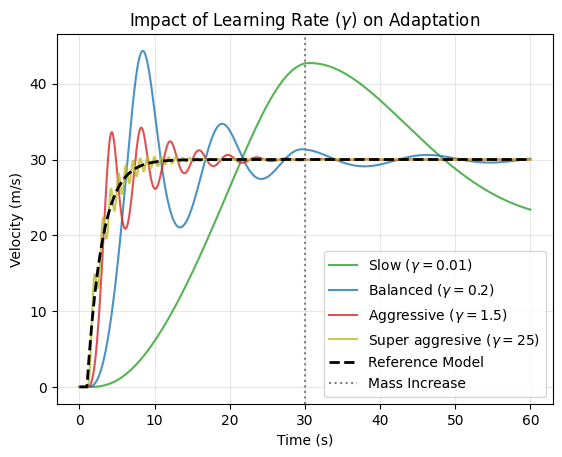

In [42]:
def simulate_mrac(gamma):
    dt, T = 0.01, 60
    time = np.arange(0, T, dt)
    
    # Plant & Model Params
    a_m, b_m = -0.5, 0.5
    m, b_const = 1000.0, 50.0 # Initial car
    
    # States
    v, v_m = 0.0, 0.0
    Kr, Kx = 0.0, 0.0
    
    history = {
        'v': [], 'v_m': [], 'Kr': [], 'Kx': [], 'cost': []
    }
    
    for t in time:
        r = 30.0 if t > 1.0 else 0.0
        
        current_m = 2500.0 if t > 30.0 else 1000.0
        
        # Controller & Dynamics
        u = Kr * r - Kx * v
        dv_dt = -(b_const/current_m) * v + (1/current_m) * u
        v += dv_dt * dt
        
        dvm_dt = a_m * v_m + b_m * r
        v_m += dvm_dt * dt
        
        # Adaptation
        error = v - v_m
        cost = 0.5 * (error**2)
        
        Kr += (-gamma * error * r) * dt
        Kx += (gamma * error * v) * dt
        
        history['v'].append(v)
        history['v_m'].append(v_m)
        history['Kr'].append(Kr)
        history['Kx'].append(Kx)
        history['cost'].append(cost)
        
    return time, history

# Test different Gammas
gammas = [0.01, 0.2, 1.5, 25]
labels = ['Slow ($\gamma=0.01$)', 'Balanced ($\gamma=0.2$)', 'Aggressive ($\gamma=1.5$)', 'Super aggresive ($\gamma=25$)']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:olive']

history = {}

for g in gammas:
    t, hist = simulate_mrac(g)
    history[g] = hist

for g, l, c in zip(gammas, labels, colors):
    hist = history[g]
    plt.plot(t, hist["v"], label=l, color=c, alpha=0.8)
    
plt.plot(t, v_m, 'k--', label='Reference Model', linewidth=2)
plt.axvline(x=30, color='gray', linestyle=':', label='Mass Increase')
plt.title('Impact of Learning Rate ($\gamma$) on Adaptation')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### Gradients

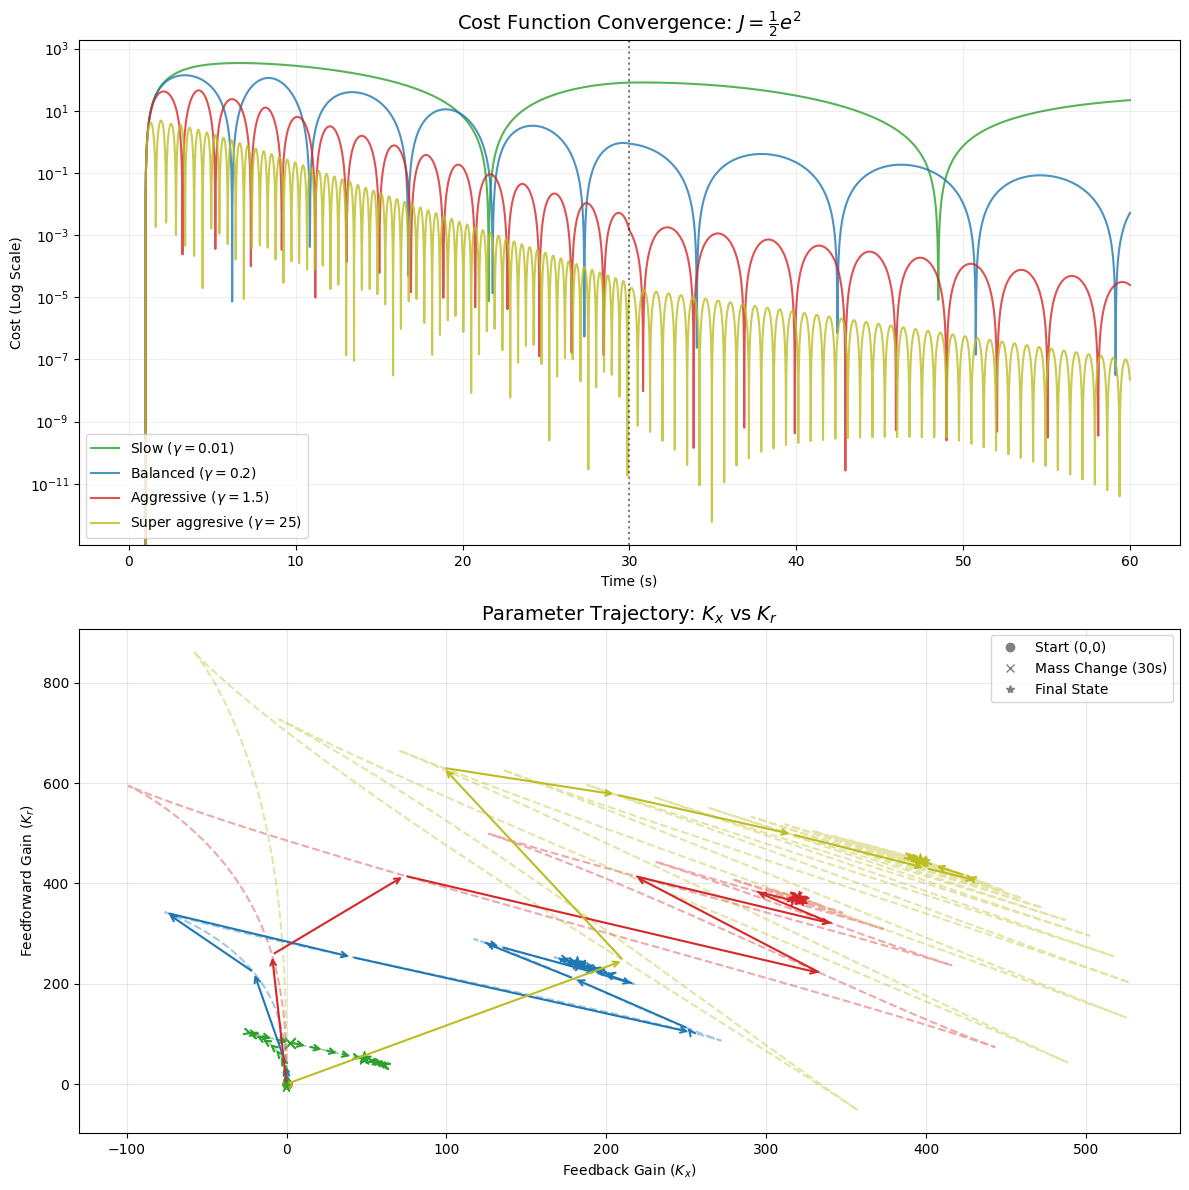

In [43]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

for g, l, c in zip(gammas, labels, colors):
    hist = history[g]
    
    # Cost Function over Time
    ax1.plot(t, hist['cost'], label=l, color=c, alpha=0.8)
    
    # Parameter Space (Kx vs Kr)
    kx = np.array(hist['Kx'])
    kr = np.array(hist['Kr'])
    
    # Draw trajectory line
    ax2.plot(kx, kr, color=c, alpha=0.4, linestyle='--')
    
    # Add arrows to show direction (Downsampled for clarity)
    skip = 200 # Draw arrow every 2 seconds
    for i in range(0, len(kx) - skip, skip):
        ax2.annotate('', xy=(kx[i+skip], kr[i+skip]), xytext=(kx[i], kr[i]),
                     arrowprops=dict(arrowstyle='->', color=c, lw=1.5))
    
    # Mark specific points
    ax2.scatter(kx[0], kr[0], color=c, marker='o', s=40) # Start
    idx_30s = int(30/0.01)
    ax2.scatter(kx[idx_30s], kr[idx_30s], color=c, marker='x', s=60) # Mass Change
    ax2.scatter(kx[-1], kr[-1], color=c, marker='*', s=100) # Final

# Formatting Cost Plot
ax1.set_yscale('log')
ax1.set_title('Cost Function Convergence: $J = \\frac{1}{2}e^2$', fontsize=14)
ax1.set_ylabel('Cost (Log Scale)')
ax1.set_xlabel('Time (s)')
ax1.axvline(x=30, color='k', linestyle=':', alpha=0.5)
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Formatting Parameter Plot
ax2.set_title('Parameter Trajectory: $K_x$ vs $K_r$', fontsize=14)
ax2.set_xlabel('Feedback Gain ($K_x$)')
ax2.set_ylabel('Feedforward Gain ($K_r$)')
ax2.grid(True, alpha=0.3)

# Add a manual legend for markers to the second plot
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='gray', label='Start (0,0)', linestyle='None'),
                   Line2D([0], [0], marker='x', color='gray', label='Mass Change (30s)', linestyle='None'),
                   Line2D([0], [0], marker='*', color='gray', label='Final State', linestyle='None')]
ax2.legend(handles=legend_elements + ax2.get_legend_handles_labels()[0])

plt.tight_layout()
plt.show()

# Initalization

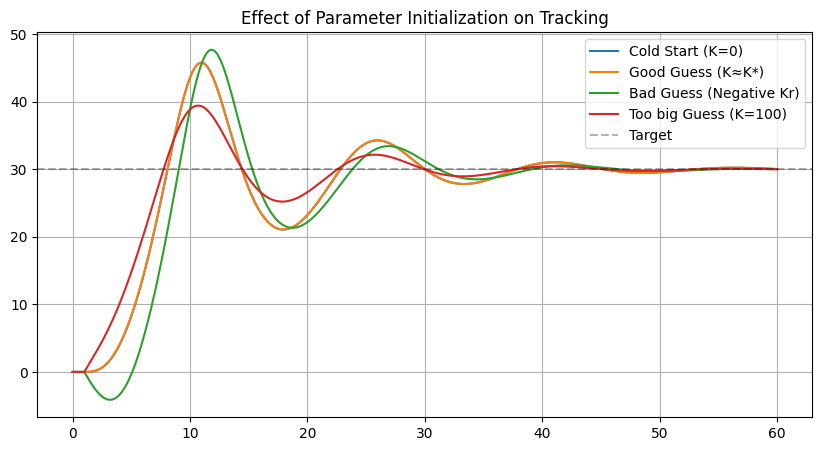

In [60]:

def simulate_init_effect(init_Kr, init_Kx, label):
    dt, T = 0.01, 60
    time = np.arange(0, T, dt)
    
    a_m, b_m = -0.5, 0.5
    m, b_p = 1000.0, 50.0
    gamma = 0.1
    
    v, v_m = 0.0, 0.0
    Kr, Kx = init_Kr, init_Kx
    v_hist, kr_hist = [], []
    
    for t in time:
        r = 30.0 if t > 1.0 else 0.0
        u = Kr * r - Kx * v
        dv_dt = -(b_p/m) * v + (1/m) * u
        v += dv_dt * dt
        v_m += (a_m * v_m + b_m * r) * dt
        
        error = v - v_m
        Kr += (-gamma * error * r) * dt
        Kx += (gamma * error * v) * dt
        v_hist.append(v)
        kr_hist.append(Kr)
        
    return time, v_hist, kr_hist

# Scenarios
plt.figure(figsize=(10, 5))
t, v_cold, _ = simulate_init_effect(0.0, 0.0, "Cold Start")
t, v_good, _ = simulate_init_effect(1.0, 0.4, "Good Guess") # Close to optimal
t, v_wrong, _ = simulate_init_effect(-100.0, -20.0, "Wrong Guess")
t, v_big, _ = simulate_init_effect(100.0, 100.0, "Too big Guess")

plt.plot(t, v_cold, label="Cold Start (K=0)")
plt.plot(t, v_good, label="Good Guess (K≈K*)")
plt.plot(t, v_wrong, label="Bad Guess (Negative Kr)")
plt.plot(t, v_big, label="Too big Guess (K=100)")
plt.axhline(y=30, color='k', linestyle='--', alpha=0.3, label="Target")
plt.title("Effect of Parameter Initialization on Tracking")
plt.legend()
plt.grid()
plt.show()

## Other resources
* https://www.youtube.com/watch?v=GBBXZXmb8UE&t=315s
* https://aleksandarhaber.com/simulation-of-model-reference-adaptive-controller-in-matlab-part-i-mit-rule-and-a-first-order-system/
* https://ntrs.nasa.gov/api/citations/20120016810/downloads/20120016810.pdf